In [2]:
#the preprocessing environment works for this script
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import pandas as pd

# Replace this with the path to one of your .h5 files
h5_path = "/home/pedro/Linux-AntigravityProjects/SurroGrid-linux/GridExpand/4.powerflow/Output/ELIAS_0_N2819500E4261500_86165_2_40_PV100_HP100_EV100_VarTar0_CapPr0(1).h5"

# See what's inside the HDF5 file
with pd.HDFStore(h5_path, mode='r') as store:
    keys = store.keys()
    print("Available tables in this file:")
    for k in keys:
        print(f" - {k}")


Available tables in this file:
 - /urbs_out/tsam/kept_timesteps
 - /urbs_out/reduced_data/buy_sell_price
 - /urbs_out/reduced_data/commodity
 - /urbs_out/reduced_data/demand
 - /urbs_out/reduced_data/eff_factor
 - /urbs_out/reduced_data/global_prop
 - /urbs_out/reduced_data/process
 - /urbs_out/reduced_data/process_commodity
 - /urbs_out/reduced_data/site
 - /urbs_out/reduced_data/storage
 - /urbs_out/reduced_data/supim
 - /urbs_out/reduced_data/type_period
 - /urbs_out/reduced_data/weather
 - /urbs_out/MILP/cap_pro
 - /urbs_out/MILP/cap_pro_new
 - /urbs_out/MILP/cap_sto_c
 - /urbs_out/MILP/cap_sto_c_new
 - /urbs_out/MILP/cap_sto_p
 - /urbs_out/MILP/cap_sto_p_new
 - /urbs_out/MILP/costs
 - /urbs_out/MILP/dt
 - /urbs_out/MILP/e_co_buy
 - /urbs_out/MILP/e_co_sell
 - /urbs_out/MILP/e_pro_in
 - /urbs_out/MILP/e_pro_out
 - /urbs_out/MILP/e_sto_con
 - /urbs_out/MILP/e_sto_in
 - /urbs_out/MILP/e_sto_out
 - /urbs_out/MILP/pro_cap_expands
 - /urbs_out/MILP/tau_pro
 - /urbs_out/MILP/weight
 - /u

In [5]:
import h5py
import pandapower as pp

# 1. Read the network JSON string from the HDF5 file
with h5py.File(h5_path, 'r') as f:
    net_json = f['raw_data/net'][()]
    if isinstance(net_json, bytes):
        net_json = net_json.decode('utf-8')

# 2. Reconstruct the pandapower network object
net = pp.from_json_string(net_json)

# 3. Display network summary
display(net)


This pandapower network includes the following parameter tables:
   - bus (30 elements)
   - load (14 elements)
   - ext_grid (1 element)
   - line (28 elements)
   - trafo (1 element)
   - line_geodata (28 elements)
   - bus_geodata (30 elements)

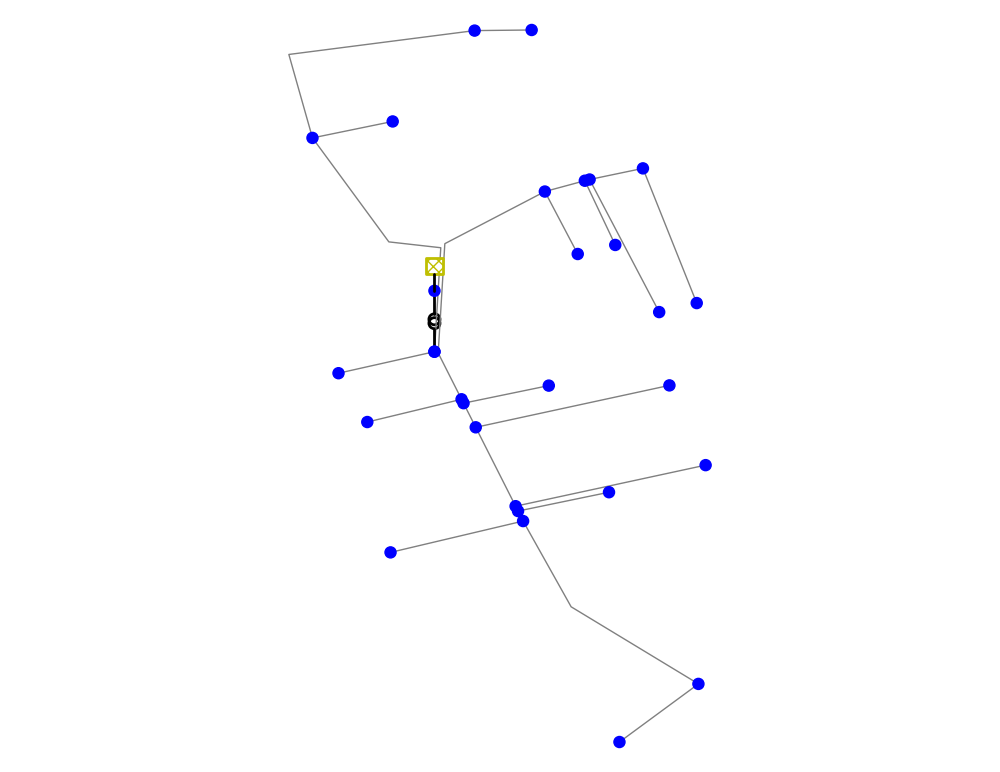

<Axes: >

In [6]:
pp.plotting.simple_plot(net)


In [ ]:
# Threshold for short lines
threshold_km = 0.015  # 15 meters

# 1. Total line calculations
total_length_km = net.line['length_km'].sum()

# 2. Short lines (< 0.015 km) calculations
short_lines = net.line[net.line['length_km'] < threshold_km]
short_count = len(short_lines)
short_length_km = short_lines['length_km'].sum()

# Print statistics
print("=== All Lines ===")
print(f"Total number of lines : {len(net.line)}")
print(f"Total line length     : {total_length_km:.3f} km")
print(f"Average line length   : {net.line['length_km'].mean() * 1000:.4f} m")
print(f"Shortest line         : {net.line['length_km'].min() * 1000:.4f} m")
print(f"Longest line          : {net.line['length_km'].max() * 1000:.4f} m")

print(f"\n=== Short Lines (< {threshold_km * 1000:.0f} m / {threshold_km} km) ===")
print(f"Short lines count     : {short_count} ({short_count / len(net.line) * 100:.1f}% of lines)")
print(f"Sum of short lines    : {short_length_km:.4f} km")
pritn(f"PERCENTAGE OF TOTAL LINE LENGTH BELONGING TO SHORT LINES:{short_length_km/total_length:.4f} ")

# Display the short lines table (if any exist)
if short_count > 0:
    print("\nShort lines preview:")
    display(short_lines[['name', 'from_bus', 'to_bus', 'length_km', 'std_type', 'in_service']])
else:
    print("\nNo lines shorter than 0.015 km found.")


=== All Lines ===
Total number of lines : 28
Total line length     : 0.640 km
Average line length   : 22.8423 m
Shortest line         : 0.0010 m
Longest line          : 70.8079 m

=== Short Lines (< 15 m / 0.015 km) ===
Short lines count     : 10 (35.7% of lines)
Sum of short lines    : 0.0562 km

Short lines preview:


,name,from_bus,to_bus,length_km,std_type,in_service
0,Line to 5190,15,21,0.010414,NYY 4x16 SE,True
5,Line to 2804,0,2,0.000001,NYY 4x70 SE,True
14,Line to 1476,7,8,0.002893,NYY 4x70 SE,True
15,Line to 5194,6,7,0.001405,NYY 4x70 SE,True
17,Line to 5705,4,5,0.006972,NYY 4x70 SE,True
18,Line to 2802,3,4,0.001126,NYY 4x70 SE,True
19,Line to 2801,0,3,0.014343,NYY 4x70 SE,True
24,Line to 5753,11,13,0.010211,NYY 4x16 SE,True
25,Line to 5755,10,11,0.000928,NYY 4x16 SE,True
26,Line to 5749,9,10,0.007882,NYY 4x16 SE,True


In [2]:
# Read the full demand dataframe
df = pd.read_hdf(h5_path, key='/urbs_in/demand')

# Filter for just Bus ID 350
# Note: 
#       
df_bus_350 = df.xs(362, level=0, axis=1)
    # axis=0 would search down the rows (timesteps)
    #axis=1 tells pandas to search across the columns (headers) to find the level=0 value of 350

# Display the results (display is built-in to Jupyter, no import needed!)
display(df_bus_350.head(10))


,electricity,space_heat,water_heat,mobility0
t,,,,
0,0.000000,1.316654,0.0,0.0
1,0.000000,1.332011,0.0,0.0
2,0.000000,1.346210,0.0,0.0
3,0.000000,1.358760,0.0,0.0
4,0.000000,1.370472,0.0,0.0
5,0.000000,1.380819,0.0,0.0
6,0.002713,1.389947,0.0,0.0
7,0.019025,1.394729,0.0,0.0
8,0.053433,1.394685,0.0,0.0


In [3]:
# Calculate the average (mean), lowest (min), and highest (max) for each commodity
summary_stats = df_bus_350.agg(['mean', 'min', 'max'])

# Display the summary table
display(summary_stats)


,electricity,space_heat,water_heat,mobility0
mean,0.102377,0.510976,0.144878,0.228837
min,0.000000,0.000000,0.000000,0.000000
max,0.565099,2.369265,0.743160,54.900000


In [4]:
# 1. Read the post-URBS optimization results
df_tau = pd.read_hdf(h5_path, key='/urbs_out/MILP/tau_pro')

# 2. Filter for Bus ID 350 (in this table, the Bus ID is stored in the 'sit' index level)
df_tau_350 = df_tau.xs(350, level='sit')

# 3. We only care about electricity imports and feed-ins (exports)
mask = df_tau_350.index.get_level_values('pro').isin(['import', 'feed_in'])
df_tau_350_elec = df_tau_350[mask]

# 4. Unstack the 'pro' level so 'import' and 'feed_in' become separate columns
df_elec_unstacked = df_tau_350_elec.unstack(level='pro')

# 5. Extract the series (handling cases where a building might not have solar/feed-in)
import_series = df_elec_unstacked['import'] if 'import' in df_elec_unstacked.columns else 0
feed_in_series = df_elec_unstacked['feed_in'] if 'feed_in' in df_elec_unstacked.columns else 0

# Net load is what the building is drawing from the grid (Import - Export)
net_load = import_series - feed_in_series

# 6. Calculate and print the peaks
print(f"Peak Energy Import: {import_series.max().item():.2f} kW")
print(f"Peak Energy Export (Feed-in): {feed_in_series.max().item():.2f} kW")
print(f"Peak Net Load: {net_load.max().item():.2f} kW")


Peak Energy Import: 1608.83 kW
Peak Energy Export (Feed-in): 916.03 kW
Peak Net Load: 1608.83 kW


In [5]:


# Read the consumers dataframe
df_consumers = pd.read_hdf(h5_path, key='/raw_data/consumers')

# Display the total count and the first 10 rows
print(f"Total consumers mapped: {len(df_consumers)}")
display(df_consumers.head(10))


Total consumers mapped: 293


,bus,name
244,244,Consumer Nodebus 7527
245,245,Consumer Nodebus 7534
246,246,Consumer Nodebus 7538
247,247,Consumer Nodebus 7545
248,248,Consumer Nodebus 7568
249,249,Consumer Nodebus 7596
250,250,Consumer Nodebus 7598
251,251,Consumer Nodebus 7614
252,252,Consumer Nodebus 7620
253,253,Consumer Nodebus 7641


In [6]:
# Read the buildings dataframe from the HDF5 file
# This table contains all the specific information about each building (e.g., area, geometry, etc.)
df_buildings = pd.read_hdf(h5_path, key='/raw_data/buildings')

# Let's see how many buildings we have in total
print(f"Total buildings found: {len(df_buildings)}")

# The 'columns' property gives us a list of all the different pieces of information available for each building
print("\nColumns available for each building:")
for col in df_buildings.columns:
    print(f" - {col}")

# Finally, let's display the first 5 rows to see what the data actually looks like
display(df_buildings.head(5))


Total buildings found: 293

Columns available for each building:
 - bus
 - vertice_id
 - type
 - height
 - use
 - houses_per_building
 - occupants
 - floors
 - constructi
 - area
 - lat
 - lon
 - roofs
 - occ_list
 - demand_tot_list
 - heating_type
 - cars_by_flat
 - n_cars_tot
 - car_dict


,bus,vertice_id,type,height,use,houses_per_building,occupants,floors,constructi,area,lat,lon,roofs,occ_list,demand_tot_list,heating_type,cars_by_flat,n_cars_tot,car_dict
0,244,7527,gastronomy,5.469,Commercial,1,2.0,1,1919-1948,36.067,54.698525,-55.539048,"[(1.967, 0, 0)]",[2.0],[3925.608381369996],radiator,[1],1,"{(244, 0): {'model': 'Fiat 500e', 'schedule': ..."
1,245,7534,SFH,6.710,Residential,1,2.0,2,1949-1978,101.239,54.698480,-55.538874,"[(5.522, 0, 0)]",[2.0],[4207.760755102762],radiator,[1],1,"{(245, 0): {'model': 'Skoda Enyaq', 'schedule'..."
2,246,7538,trade_retail,6.681,Commercial,1,2.0,2,1991-2000,133.429,54.698838,-55.539800,"[(8.852, 28, 112), (8.852, 28, 292)]",[2.0],[37963.548115913974],radiator,[1],1,"{(246, 0): {'model': 'BMW i3 BEV', 'schedule':..."
3,247,7545,gastronomy,6.693,Commercial,1,2.0,2,1991-2000,133.157,54.698970,-55.540067,"[(9.409, 34, 35), (9.409, 34, 215)]",[2.0],[28986.177682539972],floor,[1],1,"{(247, 0): {'model': 'Mercedes-Benz EQC', 'sch..."
4,248,7568,MFH,9.776,Residential,3,5.0,2,1979-1990,197.394,54.697135,-55.534825,"[(12.978, 27, 2), (12.978, 27, 182)]","[2.0, 1.0, 2.0]","[3569.458485689375, 1965.3086021952176, 3545.4...",radiator,"[1, 1, 1]",3,"{(248, 0): {'model': 'Skoda Enyaq', 'schedule'..."
